# 🧬 Cell Tracking — Approach & Local Baseline

**Competition:** [Biohub – Cell Tracking During Development](https://www.kaggle.com/competitions/biohub-cell-tracking-during-development)
— detect cells in 3D+time microscopy and reconstruct their lineage graph (nodes = detections, edges = links across time, plus divisions).

This notebook walks through our **classical baseline** end-to-end and scores it **locally** against the official metric,
so we can iterate without spending Kaggle submissions. The pipeline logic lives in the importable `pipeline/` package;
this notebook is the readable narrative on top of it.

### How it's scored (and what that implies)
- Predicted nodes are matched to **sparse** ground-truth nodes by physical centroid distance, **hard 7 µm tolerance**
  (`scale z=1.625, y=x=0.40625 µm/voxel`). A predicted edge is a TP only if **both** endpoints match GT nodes joined by a GT edge.
- Score = `adjusted_edge_jaccard + 0.1·division_jaccard`, where the adjustment penalizes total node count vs. a **dense** `T_true`.

Three consequences drive our design:
1. **Localization is ~binary at 7 µm** — and since z is 4× coarser (1.625 µm/vox ⇒ 7 µm ≈ 4.3 z-voxels), **z precision is the binding constraint**.
2. **Edges away from the sparse GT are invisible** (neither TP nor FP) — they only cost via the node-count term. So we can't prune selectively; we target a global count near `T_true`.
3. **Divisions are rare & low-weight (0.1)** — deprioritize.

## Setup

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# repo root on the path (run from notebooks/ or repo root)
ROOT = Path.cwd() if (Path.cwd() / "pipeline").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(ROOT / "eval"))

from pipeline.config import PipelineConfig
from pipeline.io_zarr import VolumeSeries
from pipeline.detect import detect_cells
from pipeline.run import run_datasets
import pipeline.submission as submission

DATA = ROOT / "data" / "train"
cfg = PipelineConfig.load(ROOT / "menu.yaml")
print("config (v2_precision):", {k: getattr(cfg, k) for k in ("scale","thresh_rel","nms_radius_um","max_link_dist_um")})

config (v2_precision): {'scale': (1.625, 0.40625, 0.40625), 'thresh_rel': 0.34, 'nms_radius_um': 2.65, 'max_link_dist_um': 11.0}


## 1 · Load a dataset

Images are OME-Zarr `(T, Z, Y, X)`. We stream one timepoint `(Z, Y, X)` at a time — the same low-memory
discipline the offline/12h Kaggle notebook needs.

In [2]:
name = "6bba_d0fc38b5"          # a mid-density dataset
vs = VolumeSeries(DATA / f"{name}.zarr")
T, Z, Y, X = vs.shape
print(f"{name}: T={T} timepoints, volume=({Z},{Y},{X})  dtype={vs.dtype}")
vol = vs.volume(0)
print("frame 0 intensity range:", int(vol.min()), "→", int(vol.max()))

6bba_d0fc38b5: T=100 timepoints, volume=(64,256,256)  dtype=uint16
frame 0 intensity range: 9 → 1150


## 2 · Detection

Per volume: XY block-mean (→ ~isotropic with z) → Gaussian smooth → robust threshold → local-maxima peaks →
**intensity-weighted centroid refinement** → physical NMS. We bias toward *precise, stable centres* over raw count.
The overlay below shows detected centroids on a max-intensity Z-projection.

48 cells detected in frame 0


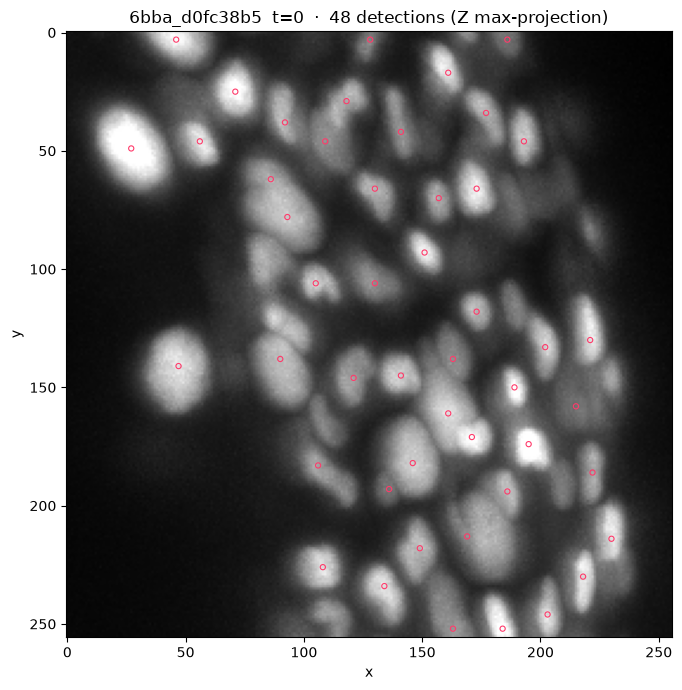

In [3]:
coords, scores = detect_cells(vol, cfg)
print(f"{len(coords)} cells detected in frame 0")

proj = vol.max(axis=0)   # Z max-projection -> (Y, X)
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(proj, cmap="gray", vmax=np.percentile(proj, 99.5))
ax.scatter(coords[:, 2], coords[:, 1], s=14, facecolors="none", edgecolors="#ff3b6b", linewidths=0.8)
ax.set_title(f"{name}  t=0  ·  {len(coords)} detections (Z max-projection)")
ax.set_xlabel("x"); ax.set_ylabel("y")
plt.tight_layout(); plt.show()

## 3 · Linking & divisions

Frame-to-frame links are one-to-one **Hungarian assignments** in physical space with an 11 µm gate.
A conservative second pass adds a division edge only when a parent already has one daughter and an unmatched
second daughter sits close to both parent and sister. Finally we prune isolated nodes (they only add node-count penalty).

We run the full pipeline on three datasets spanning the difficulty range (easy → hard by node density):

In [4]:
demo = ["6bba_2540cd90", "44b6_90724892", "44b6_551a5dba"]   # easy, mid, hard
sub_df, stats = run_datasets(DATA, demo, cfg, verbose=False)
import pandas as pd
display(pd.DataFrame(stats)[["dataset","nodes","edges","removed_isolated","count_mean","seconds"]])
submission.validate(sub_df, expected_datasets=set(demo))
print(f"submission rows: {len(sub_df):,}  (nodes {int((sub_df.row_type=='node').sum()):,}, edges {int((sub_df.row_type=='edge').sum()):,})")
sub_df.head()

,dataset,nodes,edges,removed_isolated,count_mean,seconds
0,6bba_2540cd90,2389,2322,14,24.0,4.9
1,44b6_90724892,7332,6482,332,76.6,5.4
2,44b6_551a5dba,11392,9938,715,121.1,5.8


submission rows: 39,855  (nodes 21,113, edges 18,742)


,id,dataset,row_type,node_id,t,z,y,x,source_id,target_id
0,0,6bba_2540cd90,node,1,0,5,178,62,-1,-1
1,1,6bba_2540cd90,node,2,0,8,199,214,-1,-1
2,2,6bba_2540cd90,node,3,0,14,26,26,-1,-1
3,3,6bba_2540cd90,node,4,0,14,134,186,-1,-1
4,4,6bba_2540cd90,node,5,0,21,245,90,-1,-1


## 4 · Local scoring (official metric)

We score the prediction against the paired `.geff` ground truth using the organizers' vendored metric —
the same numbers the leaderboard computes.

In [5]:
from local_eval import score_submission
sub_path = ROOT / "submissions" / "_nb_demo.csv"
submission.save(sub_df, sub_path)
summary = score_submission(sub_path, DATA, demo)
print(f"\n3-dataset demo  SCORE={summary['score']:.4f}  "
      f"edge_jaccard={summary['edge_jaccard']:.4f}  node_recall={summary['node_recall']:.4f}")

  [6bba_2540cd90] edge_J=0.9430 adj_edge_J=0.9777 nodes=2389 (T_true=3783) recall=0.962
  [44b6_90724892] edge_J=0.5727 adj_edge_J=0.6136 nodes=7332 (T_true=25532) recall=0.676


  [44b6_551a5dba] edge_J=0.1379 adj_edge_J=0.1490 nodes=11392 (T_true=57627) recall=0.289

3-dataset demo  SCORE=0.6919  edge_jaccard=0.6633  node_recall=0.6426


/Users/reillykoren/biohub-kaggle/eval/_vendor/tracking_cellmot/metrics.py:426: UserWarning: No divisions present across any sample in this split; dropping division term from the combined score.
  warnings.warn(


The three demo datasets show the pattern clearly: score tracks **node recall** and collapses on dense, high-`T_true` datasets.

**Full 13-dataset dev-subset baseline** (`python -m pipeline.run --subset-json eval/dev_subset.json`):
`SCORE = 0.5341` · edge_jaccard 0.506 · node_recall 0.62 · division_jaccard 0.0 — the same ballpark as the
starter's **≈0.581 public LB** (one calibration point; slope needs a few spread submissions to confirm).

## 5 · Findings & next steps

- **The bottleneck is detection recall + centroid localization**, especially on dense datasets — exactly what the 7 µm cliff predicts.
  Overall node recall is 0.62; the hardest datasets sit at 0.23–0.29.
- **Node budget matters**: target total detections near `T_true` (over-prediction is penalized, under is mildly rewarded).
- **Divisions contribute ~nothing** here (sparse, 0.1 weight) — don't over-invest.

**Next:** (1) a learned 3D detector (Cellpose/StarDist/organizers' TemporalUNet3D, attached offline) to lift recall on dense volumes;
(2) sweep detection knobs on the dev subset via the local score; (3) an offline submission-notebook smoke test to de-risk the Kaggle plumbing early.